In [ ]:
import mod as m 
import numpy as np 
import matplotlib.pyplot as plt 

## Read in data

In [ ]:
date = '04-17-26'
filename = "1005Pa.txt"

arr = np.loadtxt(f"Data/HighPressureTesting-{date}/"+filename, usecols=range(1, 8))

In [3]:
ind = True 

In [4]:
x = arr[:,0]
y = arr[:,1]
z = arr[:,2]

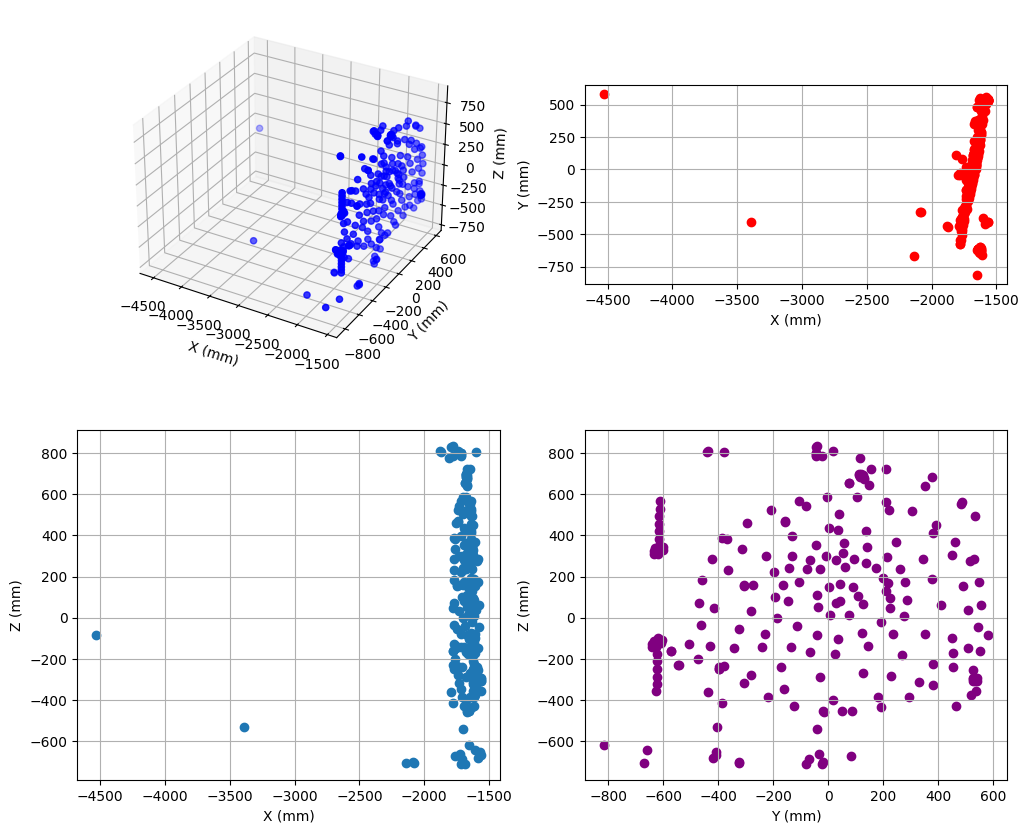

In [5]:
m.vis(x,y,z,date)

## Reference bars

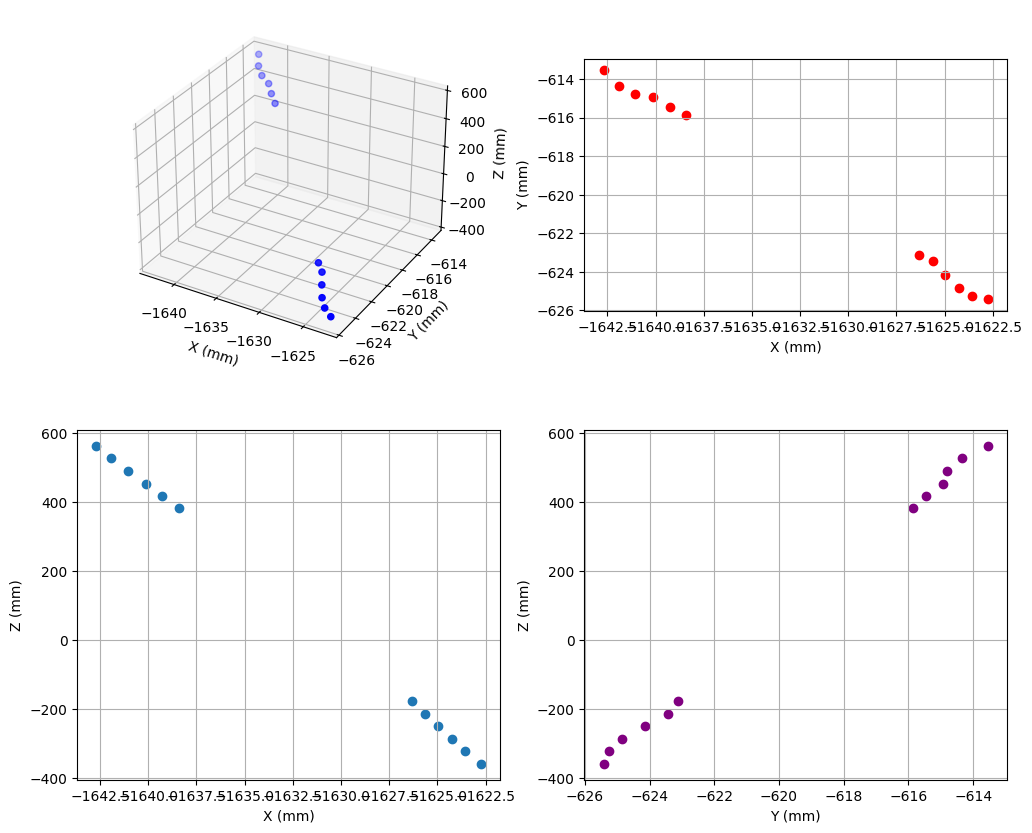

In [6]:
xb = x[4:16]
yb = y[4:16]
zb = z[4:16]

m.vis(xb, yb, zb, date)

In [ ]:
mask = (z>)

In [ ]:
ref = np.vstack([xb, yb, zb]).T  
pts = np.vstack([x, y, z]).T 
Xr, Yr, Zr, X, Y, Z, _, _ = m.svd_rotate(ref, pts)


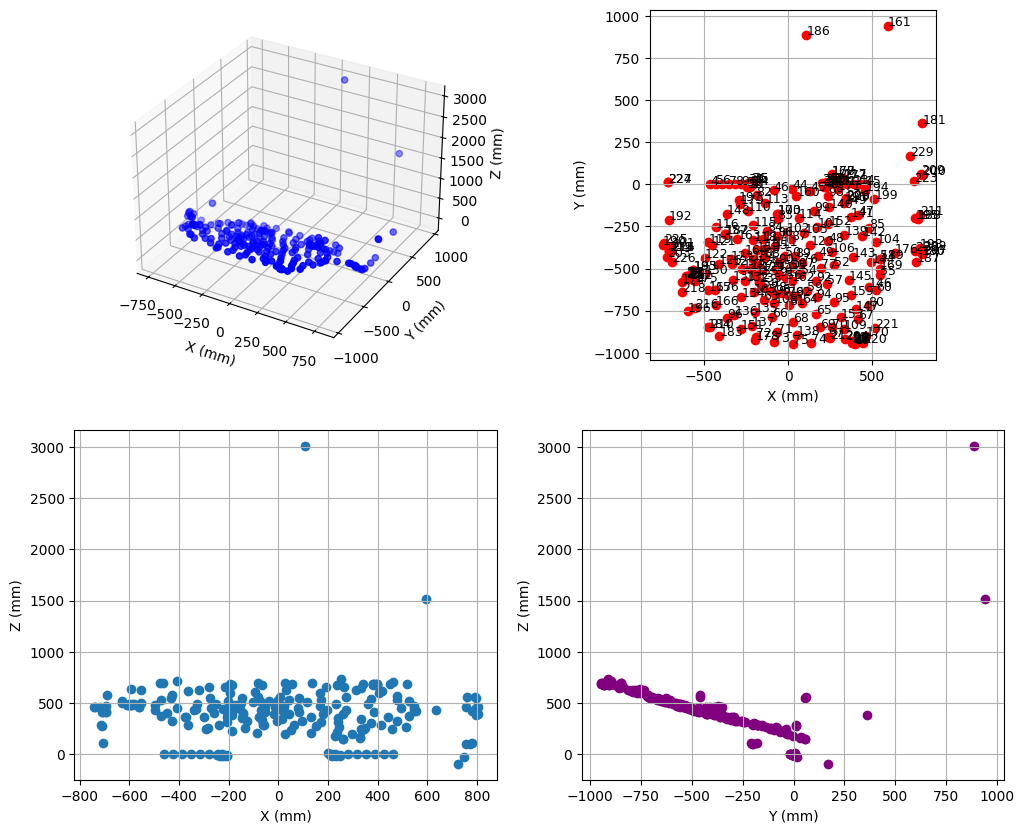

In [ ]:
m.vis(X,Y,Z, date, ind=True)

In [16]:
r = np.sqrt( X**2 + (Y+500)**2 ) 

rlim = 500
mask = r < rlim

xx = X[mask]
yy = Y[mask]
zz = Z[mask]

In [17]:
theta = np.linspace(0,360,100)
x_c = rlim * np.cos(np.deg2rad(theta)) 
y_c = rlim * np.sin(np.deg2rad(theta)) -500

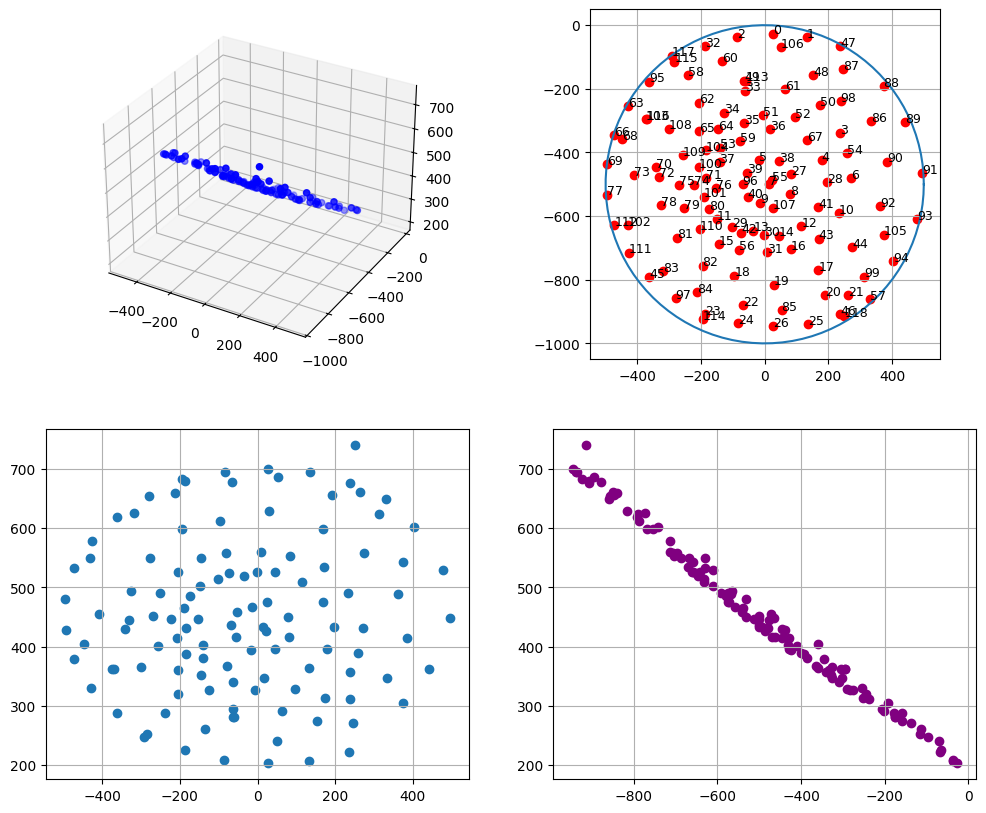

In [18]:
fig = plt.figure(figsize=(12, 10))

# 3D plot
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(xx, yy, zz, c='blue')
# ax1.set_title('3D Plot')

# XY plane
ax2 = fig.add_subplot(222)
ax2.scatter(xx, yy, c='red')
ax2.plot(x_c, y_c)
if ind:
    for i, (xi, yi) in enumerate(zip(xx, yy)):
        ax2.text(xi, yi, str(i), fontsize=9, color='black')

ax2.set_aspect("equal")
ax2.grid()

# XZ plane
ax3 = fig.add_subplot(223)
ax3.scatter(xx, zz)
ax3.grid()

# YZ plane
ax4 = fig.add_subplot(224)
ax4.scatter(yy, zz, c='purple')
ax4.grid()

In [19]:
mask = zz > 100 

xx = xx[mask]
yy = yy[mask]
zz = zz[mask]

In [20]:
pts = np.vstack([xx, yy, zz]).T  
Xr, Yr, Zr, X, Y, Z, _, _ = m.svd_rotate(pts, pts)


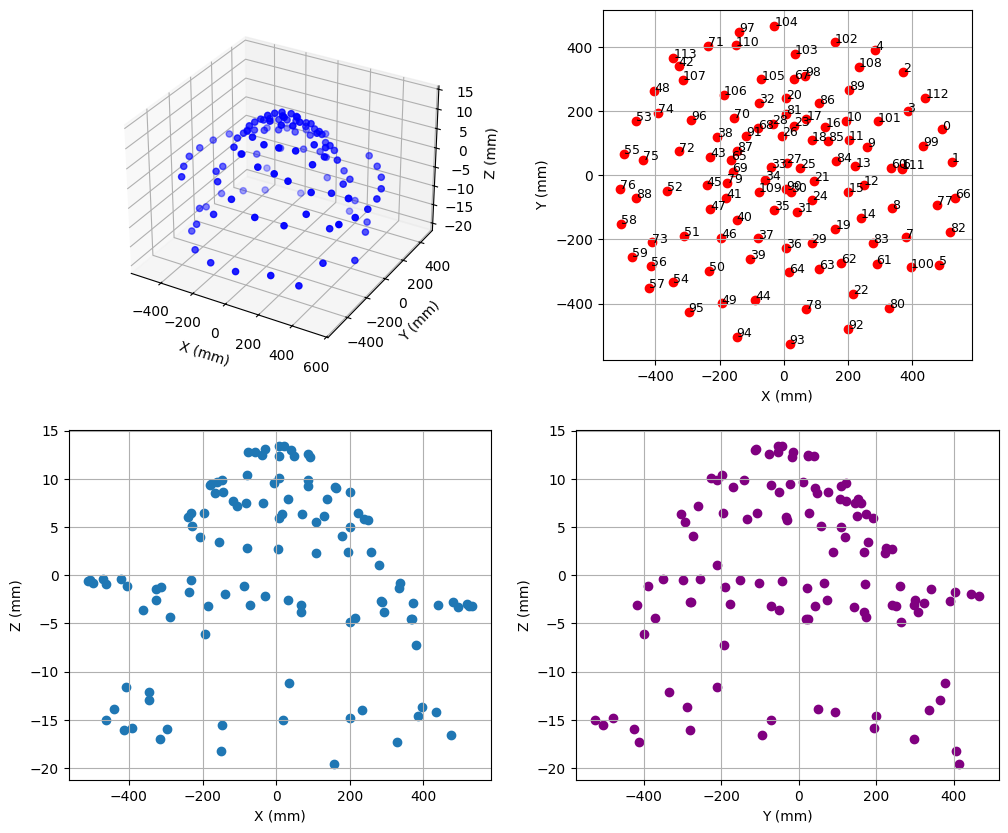

In [14]:
m.vis(X,Y,Z, date, ind=True)

In [17]:
# xp = np.delete(X, [122, 123, 124])
# yp = np.delete(Y, [122, 123, 124])
# zp = np.delete(Z, [121,122,123,124])

In [18]:
# m.vis(xp ,yp, zp, date)

In [21]:
xp, yp, zp = X, Y, Z

In [22]:
pts = np.vstack([xp, yp, zp]).T 
Xr, Yr, Zr, xp, yp, zp, _, _ = m.svd_rotate(pts, pts)

In [ ]:
r = np.sqrt( xp**2 + yp**2 ) 

rlim = 450
mask = r < rlim

xx = xp[mask]
yy = yp[mask]
zz = zp[mask]

xr = xp[~mask]
yr = yp[~mask]
zr = zp[~mask]


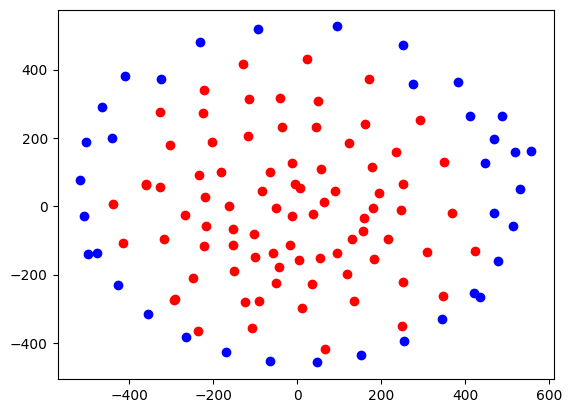

In [ ]:
fig = plt.figure(figsize=(12, 10))
fig.scatter(xx, yy, c = 'red')
fig.scatter(xr, yr, c = 'blue')



In [29]:
def write_txt_from_arrays(filename, x, y, z):
    data = np.column_stack((x, y, z))
    np.savetxt(f"Data/HighPressureTesting-{date}/"+filename, data, fmt="%.6f", delimiter="\t")


In [30]:

# write_txt_from_arrays(filename, np.append(xx, xr), np.append(yy, yr) , np.append(zz, zr))
write_txt_from_arrays("Clean-"+filename, xx, yy, zz)